# Projet de Science de Données : Automatisation de l'octroi de credits
** sci 1402
**Numéro d’étudiant:	**24120614
**Étudiant :** Meffeu Keumogne Prudence
**Société :** Dream Housing Finance  
**Méthodologie :** CRISP-DM  

# I - Compréhension des objectifs d'affaires (Business Understanding)

L’objectif premier est d'automatiser l'octroi de crédits pour gagner du temps et réduire les erreurs humaines chez **Dream Housing Finance**.

## 1.1 Traduction du problème métier en problème technique
Le défi consiste à automatiser l'évaluation de l'éligibilité au crédit. Nous formulons ce besoin comme une tâche d'**apprentissage supervisé**, plus précisément une **classification binaire**.

*   **Variable cible (Y) :** `Loan_Status` (Statut du prêt).
    *   **1 (Y) :** Prêt approuvé.
    *   **0 (N) :** Prêt refusé.
*   **Variables explicatives (X) :** Caractéristiques socio-démographiques et financières (historique de crédit, revenus, montant du prêt, etc.).

## 1.2 Définition des critères de succès (KPIs)
Toutes les erreurs n'ont pas le même coût financier pour l'entreprise.

### A. Analyse du coût de l'erreur (Matrice de confusion)
*   **Faux Positif (FP) - Le Risque Majeur :** Prédire qu'un client est solvable alors qu'il fait défaut. Cela entraîne une **perte financière directe** du capital prêté.
*   **Faux Négatif (FN) - Le Manque à gagner :** Refuser un prêt à un client qui était réellement solvable. Cela entraîne une **perte d'opportunité** au profit de la concurrence.

### B. Indicateurs de Performance (KPI SMART)
1.  **Score F1 (Métrique principale) :** Assure un équilibre entre Précision et Rappel pour ne rater ni les bons clients, ni laisser passer les mauvais.
2.  **Précision (Classe "Approved") :** Maximiser la fiabilité des accords pour minimiser les risques financiers (Faux Positifs).
3.  **Temps de réponse (Opérationnel) :** Le modèle doit répondre en moins d'une seconde pour une intégration en temps réel.

## 1.3 Analyse des risques et contraintes
*   **Qualité des données :** L'absence d'historique de crédit rend la prédiction particulièrement complexe.
*   **Biais éthique :** Nous veillerons à ce que l'algorithme n'amplifie pas de discriminations historiques (genre, zone géographique). Nous analyserons la parité des décisions à profil financier équivalent.

## II - Compréhension des données (Data Understanding)

Cette étape consiste à explorer la qualité et la pertinence des informations disponibles afin de préparer la phase de modélisation.

### 2.1 Audit de qualité initial
Avant toute analyse statistique, nous effectuons un audit technique pour identifier les anomalies dans le jeu de données. Nous nous concentrons sur deux aspects :
1.  **Les valeurs manquantes :** Identifier les informations absentes qui pourraient fausser les calculs ou empêcher l'entraînement du modèle.
2.  **Les doublons :** Vérifier l'unicité des enregistrements pour ne pas biaiser l'apprentissage.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv("train_loan_prediction.csv")

# 1. Vérification des valeurs manquantes
print("--- Valeurs manquantes par colonne ---")
print(df.isnull().sum().sort_values(ascending=False))

# 2. Vérification des doublons
print(f"\nNombre de doublons : {df.duplicated().sum()}")


--- Valeurs manquantes par colonne ---
Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

Nombre de doublons : 0


### 2.1.3 Analyse des variables numériques et détection des outliers

Nous allons maintenant examiner la distribution des revenus et du montant des prêts. L'objectif est de détecter la présence de valeurs aberrantes (outliers) qui pourraient fausser l'apprentissage de nos futurs modèles.

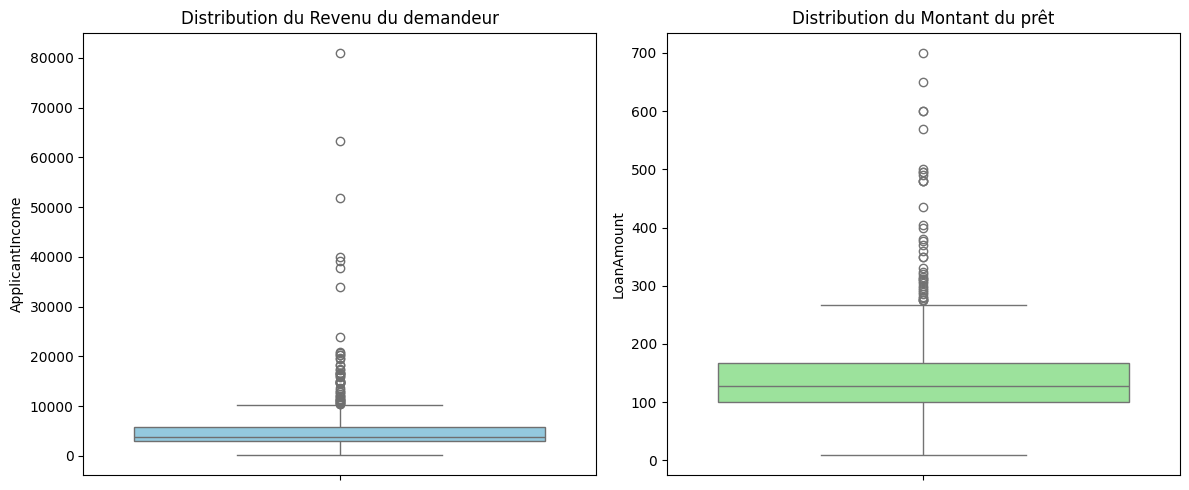

In [5]:
# Configuration de la zone de dessin
plt.figure(figsize=(12, 5))

# Graphique 1 : Revenu du demandeur
plt.subplot(1, 2, 1)
sns.boxplot(y=df['ApplicantIncome'], color='skyblue')
plt.title('Distribution du Revenu du demandeur')

# Graphique 2 : Montant du prêt
plt.subplot(1, 2, 2)
sns.boxplot(y=df['LoanAmount'], color='lightgreen')
plt.title('Distribution du Montant du prêt')

plt.tight_layout()
plt.show()

### 2.1.4 Interpretation 

Les "boîtes à moustaches" (boxplots) ci-dessus nous permettent d'observer la dispersion des données financières et d'identifier les valeurs atypiques.

#### **Observations sur le Revenu (ApplicantIncome)**
*   **Présence massive d'outliers :** La majorité des revenus se situe en dessous de 10 000 $. Cependant, nous observons de nombreux points isolés s'étendant jusqu'à **80 000 $**.
*   **Asymétrie :** La distribution est fortement étalée vers le haut (asymétrie positive), ce qui signifie qu'une petite partie de la clientèle possède des revenus très supérieurs à la moyenne.

#### **Observations sur le Montant du Prêt (LoanAmount)**
*   **Valeurs extrêmes :** La plupart des prêts demandés sont compris entre 100 et 200 (en milliers de $). Néanmoins, certains dossiers montent jusqu'à **700**, créant là aussi une longue traîne de valeurs atypiques.

#### **Impact technique pour la suite du projet :**
Ces valeurs aberrantes ne sont pas forcément des erreurs de saisie (il est normal que certains clients soient très riches), mais elles peuvent **perturber l'apprentissage** des modèles statistiques (comme la Régression Logistique) qui sont sensibles aux grands écarts.

**Décision pour la Phase III (Préparation) :**
Pour stabiliser les données et réduire l'impact de ces outliers, nous procéderons à une **transformation logarithmique** de ces variables. Cela permettra de normaliser les distributions et d'aider le modèle à mieux généraliser ses prédictions.

### 2.2 Analyse et Interprétation de l'Audit


#### **A. Fiabilité du Dataset**
*   **Doublons :** Le dataset contient **0 doublon**, ce qui garantit que chaque demande de prêt est unique et évite de fausser l'apprentissage du modèle par des répétitions.
*   **Variable Cible :** La colonne `Loan_Status` est complète (**0 manque**). C'est un excellent point, car nous disposons de la "réponse" pour chaque exemple de notre base d'entraînement.

#### **B. Analyse des Valeurs Manquantes (Missing Data)**
Nous observons que plusieurs variables clés présentent des manques :
*   **Credit_History (50 manquants) :** C'est le point le plus critique. Comme nous l'avons vu dans la problématique, l'historique de crédit est souvent le prédicteur n°1. Le traitement de ces 50 lignes sera déterminant.
*   **Variables socio-professionnelles :** `Self_Employed` (32), `Dependents` (15) et `Gender` (13) présentent des lacunes modérées.
*   **Variables financières :** `LoanAmount` (22) et `Loan_Amount_Term` (14) devront être complétées pour ne pas perdre ces enregistrements lors de la modélisation.

#### **C. Stratégie de remédiation (Preview)**
Ces observations justifient les choix que nous ferons en **Phase III (Préparation)** :
1.  **Imputation par le mode** pour les variables catégorielles (ex: Credit_History, Gender).
2.  **Imputation par la médiane** pour les variables numériques (ex: LoanAmount) afin de ne pas être influencé par les valeurs extrêmes.


C:\Users\assej\AppData\Local\Temp\ipykernel_74448\2853487065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


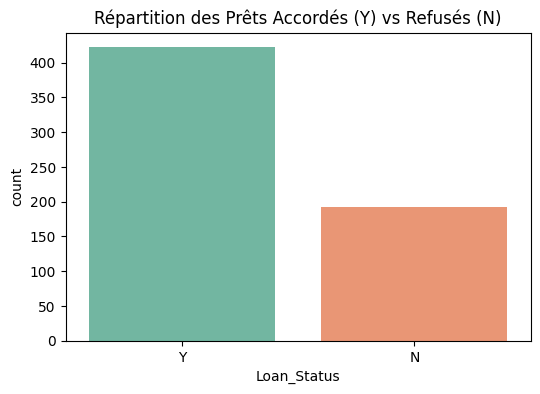

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisation de la variable cible
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Répartition des Prêts Accordés (Y) vs Refusés (N)')
plt.show()

# Pourcentage exact
print(df['Loan_Status'].value_counts(normalize=True) * 100)


### 2.3 Analyse de la Variable Cible (Loan_Status)

La première étape de notre analyse exploratoire consiste à observer la répartition des décisions de prêt historiques. 

#### **Observations clés :**
*   **Prêts Accordés (Y) :** Environ **68,7 %** (soit 422 dossiers).
*   **Prêts Refusés (N) :** Environ **31,3 %** (soit 192 dossiers).

#### **Interprétation stratégique :**
1.  **Déséquilibre de classe :** Nous constatons que le dataset est modérément déséquilibré. Il y a plus du double de prêts accordés que de prêts refusés. 
2.  **Impact sur l'évaluation :** Ce déséquilibre confirme notre choix stratégique (défini en Phase I) de ne pas nous fier uniquement à la "Précision globale" (Accuracy). Si un modèle prédisait "Oui" pour tout le monde, il aurait déjà 68 % de succès, mais il échouerait totalement à identifier les clients risqués. 
3.  **Performance à battre :** Notre modèle final devra être capable de dépasser significativement ce seuil de 68 % tout en étant particulièrement performant sur la détection de la classe minoritaire (les refus).

### 2.4 Analyse de la segmentation : Genre et Zone Géographique

Pour répondre aux objectifs marketing de Dream Housing Finance, nous analysons si le profil socio-démographique (Genre) et la localisation (Zone Géographique) influencent l'obtention du prêt.

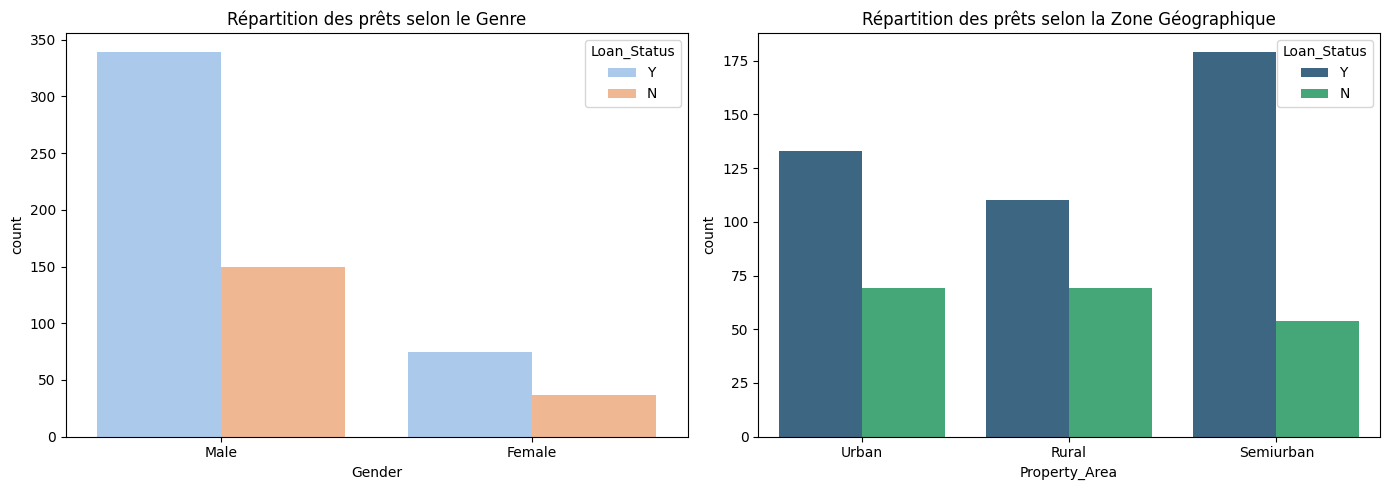

In [6]:
# Configuration de la zone de dessin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Impact du Genre
sns.countplot(x='Gender', hue='Loan_Status', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Répartition des prêts selon le Genre')

# Graphique 2 : Impact de la Zone Géographique
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Répartition des prêts selon la Zone Géographique')

plt.tight_layout()
plt.show()

### Interpretation du graphique

Ces graphiques nous permettent de répondre à la problématique marketing en identifiant les profils types des demandeurs et leur succès face à l'octroi de prêt.

#### **A. Analyse selon le Genre (Gender)**
*   **Volume de demandes :** On observe une nette prédominance des hommes (**Male**) parmi les demandeurs de prêt par rapport aux femmes (**Female**).
*   **Parité des chances :** Malgré la différence de volume, la proportion de prêts accordés (bleu) par rapport aux refusés (orange) semble équivalente pour les deux genres. 
*   **Conclusion éthique :** Le genre ne semble pas être un facteur discriminant majeur dans les décisions historiques de la banque.

#### **B. Analyse selon la Zone Géographique (Property_Area)**
C'est ici que nous observons les différences les plus marquées :
*   **Semiurban (Segment prioritaire) :** Cette zone affiche le taux de succès le plus élevé. C'est le segment où les prêts sont le plus massivement accordés avec le moins de refus proportionnels.
*   **Rural (Segment à risque) :** La zone rurale présente la proportion de refus la plus importante par rapport au nombre total de demandes dans cette zone.
*   **Urban :** Se situe dans une position intermédiaire avec une répartition équilibrée.

#### **Conclusion Stratégique (Marketing) :**
Pour optimiser son portefeuille clients, **Dream Housing Finance** devrait concentrer ses efforts de prospection sur le segment **Semi-urbain**, qui présente historiquement le taux d'éligibilité le plus élevé. Une étude complémentaire sur les garanties en zone rurale pourrait être pertinente pour comprendre le taux de refus plus élevé dans ce secteur.

### 2.5 Analyse de l'impact de l'Historique de Crédit

Ce graphique compare la présence d'un historique de crédit (1.0) ou son absence (0.0) par rapport au statut final du prêt.

c:\Users\assej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\assej\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


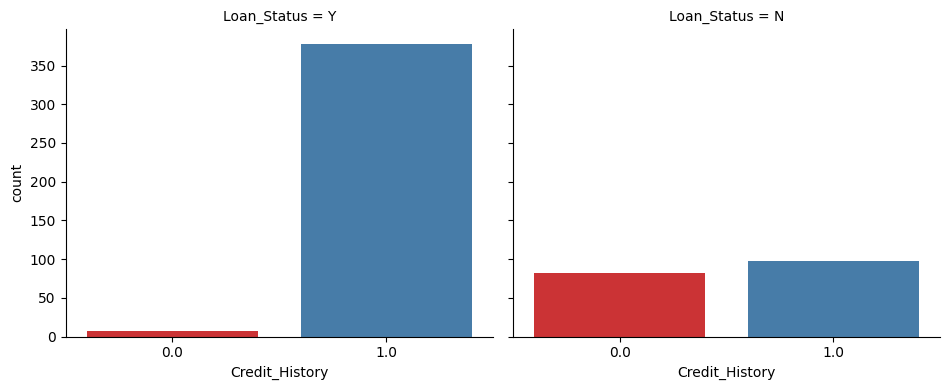

In [7]:
# Croisement entre Historique de Crédit et Statut du Prêt
grid = sns.FacetGrid(df, col='Loan_Status', height=4, aspect=1.2)
grid.map(sns.countplot, 'Credit_History', palette='Set1', order=[0.0, 1.0])
plt.show()


#### **Observations :**
*   **Pour les prêts accordés (Loan_Status = Y) :** On constate que la quasi-totalité des clients approuvés possèdent un historique de crédit positif.
*   **Pour les prêts refusés (Loan_Status = N) :** Une part très importante des refus concerne des clients n'ayant aucun historique de crédit (0.0).

#### **Conclusion technique :**
L'historique de crédit apparaît comme le **facteur discriminant numéro 1**. Cette observation est fondamentale pour notre modèle prédictif. Elle souligne également l'importance critique des 50 valeurs manquantes identifiées lors de l'audit : le traitement de ces données absentes aura un impact majeur sur la fiabilité de nos prédictions finales.

# III - Préparation des données (Data Preparation)

Cette phase consiste à nettoyer le dataset et à transformer les variables pour optimiser l'apprentissage du modèle. Nous allons procéder en trois étapes :
1. **Traitement des valeurs manquantes** (Imputation).
2. **Ingénierie des caractéristiques** (Création de la variable Revenu Total).
3. **Transformation et Encodage** (Logarithme pour les outliers et conversion des textes en chiffres).

### 3.1 Traitement des valeurs manquantes (Imputation)

L'audit de la phase II a révélé plusieurs colonnes incomplètes. Nous appliquons les stratégies suivantes :
*   **Variables catégorielles :** Imputation par le **Mode** (valeur la plus fréquente). C'est le cas pour l'historique de crédit, le sexe et le statut matrimonial.
*   **Variables numériques :** Imputation par la **Médiane**. Nous préférons la médiane à la moyenne car elle est plus robuste face aux valeurs aberrantes (outliers) que nous avons identifiées précédemment.

In [8]:
df_prep = df.copy()

# Imputation par le Mode
cols_cat = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cols_cat:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

# Imputation par la Médiane
df_prep['LoanAmount'] = df_prep['LoanAmount'].fillna(df_prep['LoanAmount'].median())
df_prep['Loan_Amount_Term'] = df_prep['Loan_Amount_Term'].fillna(df_prep['Loan_Amount_Term'].median())

print("✅ Valeurs manquantes traitées.")

✅ Valeurs manquantes traitées.


### 3.2 Ingénierie des caractéristiques (Feature Engineering)

La capacité de remboursement d'un client dépend souvent de la richesse globale de son foyer plutôt que de son seul revenu personnel. Nous créons la variable **Total_Income** (Revenu du demandeur + Revenu du conjoint) pour fournir au modèle une vision financière plus complète.

In [9]:
# Création du revenu total
df_prep['Total_Income'] = df_prep['ApplicantIncome'] + df_prep['CoapplicantIncome']
df_prep.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0


### 3.3 Transformation logarithmique

Pour traiter les valeurs aberrantes (outliers) observées lors des boxplots, nous appliquons une transformation logarithmique. Cela permet de compresser les écarts de revenus et de normaliser la distribution des données, ce qui stabilise l'apprentissage des modèles de classification.

In [12]:
# Application du Logarithme pour stabiliser les données
df_prep['Total_Income_log'] = np.log(df_prep['Total_Income'])
df_prep['LoanAmount_log'] = np.log(df_prep['LoanAmount'])

# Suppression sécurisée de la colonne Loan_ID
# errors='ignore' permet de ne pas avoir d'erreur si on relance la cellule
df_prep = df_prep.drop('Loan_ID', axis=1, errors='ignore')

print("✅ Transformation Log terminée et colonne Loan_ID supprimée.")
df_prep.head(2)

✅ Transformation Log terminée et colonne Loan_ID supprimée.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,8.674026,4.85203
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.714568,4.85203


### 3.4 Encodage des variables qualitatives

Les algorithmes de Machine Learning ne traitent que des valeurs numériques. Nous utilisons le **LabelEncoder** pour convertir les catégories textuelles (ex: Male/Female, Urban/Rural) en entiers (0, 1, 2).

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Dependents']

for col in target_cols:
    df_prep[col] = le.fit_transform(df_prep[col])

print("✅ Encodage terminé.")
df_prep.head()

✅ Encodage terminé.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,8.674026,4.852030
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.714568,4.852030
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006368,4.189655
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,8.505323,4.787492
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,8.699515,4.948760


## IV - Modélisation (Modeling)

Dans cette phase, nous allons entraîner deux types de modèles pour comparer leurs performances :
1. **Régression Logistique :** Un modèle simple, rapide et très utilisé dans le secteur bancaire pour son interprétabilité.
2. **Random Forest (Forêt Aléatoire) :** Un modèle plus robuste capable de capturer des relations complexes entre les variables.

**Méthodologie :**
*   Nous diviserons nos données en deux ensembles : **Entraînement (80%)** et **Test (20%)**.
*   Nous utiliserons le **Grid Search** avec **Validation Croisée** pour optimiser les performances du Random Forest.

### 4.1 Préparation des vecteurs (X, y) et Split 80/20
Nous séparons la variable cible `Loan_Status` (y) des autres caractéristiques (X). Pour évaluer la fiabilité de nos modèles, nous divisons le dataset en deux :
*   **Ensemble d'entraînement (80%) :** Pour permettre aux modèles d'apprendre les motifs de décision.
*   **Ensemble de test (20%) :** Pour évaluer la performance sur des données inconnues.

In [14]:
from sklearn.model_selection import train_test_split

# Définition de X (caractéristiques) et y (cible)
X = df_prep.drop(['Loan_Status', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income'], axis=1)
y = df_prep['Loan_Status']

# Division 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Division terminée : {X_train.shape[0]} lignes d'entraînement et {X_test.shape[0]} lignes de test.")

✅ Division terminée : 491 lignes d'entraînement et 123 lignes de test.


### 4.2 Modèle 1 : Régression Logistique

La Régression Logistique est notre modèle de base (baseline). Elle est largement utilisée dans le secteur bancaire car elle permet d'obtenir un score de probabilité facilement interprétable par les agents de crédit. C'est un modèle rapide et robuste pour les problèmes de classification binaire.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Entraînement du modèle
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred_lr = model_lr.predict(X_test)

print(f"Régression Logistique - Accuracy : {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Régression Logistique - Score F1 : {f1_score(y_test, y_pred_lr):.2f}")

Régression Logistique - Accuracy : 0.79
Régression Logistique - Score F1 : 0.86




### 4.2.1 Interprétation :
1.  **Efficacité immédiate :** Avec une précision de 79 %, ce modèle simple surpasse déjà largement le hasard. Il valide notre phase de préparation des données (imputation et transformation logarithmique).
2.  **Robustesse du Score F1 :** Le score de 0.86 confirme que le modèle est particulièrement performant pour identifier les clients éligibles. Cela répond à l'objectif opérationnel de Dream Housing Finance : automatiser les accords de prêt de manière fiable.
3.  **Baseline solide :** Ces résultats constituent une "base de référence" (baseline) très haute. Pour que le Random Forest soit considéré comme supérieur, il devra montrer des scores encore plus élevés ou une meilleure détection des clients risqués.

**Étape suivante :** Nous allons maintenant tester le **Random Forest** pour voir si un algorithme plus complexe peut améliorer ces scores ou apporter une meilleure finesse de prédiction.

### 4.3 Modèle 2 : Random Forest avec Optimisation (Grid Search)

Le Random Forest est un algorithme d'ensemble plus puissant qui crée une multitude d'arbres de décision. Pour en tirer le meilleur parti, nous utilisons la technique du **Grid Search** combinée à une **Validation Croisée (CV=5)**. Cette méthode teste plusieurs combinaisons d'hyperparamètres (profondeur des arbres, nombre d'estimateurs) afin de trouver la configuration la plus stable et performante.

Au lieu de tester le modèle une seule fois, nous avons utilisé une validation croisée à 5 plis (5-Fold). Cela signifie que le jeu de données d'entraînement a été divisé en 5 segments. Le modèle a été entraîné et validé 5 fois, en changeant de segment de test à chaque rotation. Cette méthode garantit que la performance du modèle est stable et qu'elle ne dépend pas d'un "coup de chance" lors de la division initiale des données.
Le Grid Search a permis de tester systématiquement plusieurs combinaisons d'hyperparamètres pour le Random Forest :



In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Définition de la grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Mise en place du Grid Search (Recherche par grille)
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)

# Meilleur modèle issu de l'optimisation
best_rf = grid_rf.best_estimator_

print(f"✅ Meilleurs paramètres trouvés : {grid_rf.best_params_}")
y_pred_rf = best_rf.predict(X_test)
print(f"Random Forest Optimisé - Accuracy : {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Random Forest Optimisé - Score F1 : {f1_score(y_test, y_pred_rf):.2f}")

✅ Meilleurs paramètres trouvés : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Optimisé - Accuracy : 0.79
Random Forest Optimisé - Score F1 : 0.86


### 4.4 Conclusion de la modélisation : Choix du modèle final

Après avoir testé deux les méthodes différentes, nous constatons que les deux modèles ont le même score, nous avons décidé de retenir la **Régression Logistique** pour la suite du projet car :

1. **Simplicité :** C'est un modèle facile à comprendre et à utiliser.
2. **Rapidité :** Il demande moins de puissance de calcul.
3. **Clarté :** Dans le domaine bancaire, il est important de pouvoir expliquer simplement au client les raisons d'une décision. La Régression Logistique est parfaite pour cela.

**Décision :** Nous allons maintenant évaluer ce modèle plus en détail pour voir s'il aide vraiment la banque à limiter ses risques financiers.

# V - Évaluation (Evaluation)

Dans cette phase finale, nous vérifions la fiabilité réelle de notre modèle de **Régression Logistique** avant de le proposer à la banque. Nous utilisons quatre outils complémentaires pour mesurer sa performance.

### 5.1 La Matrice de Confusion
Ce tableau nous permet de voir le détail des bonnes et mauvaises décisions.

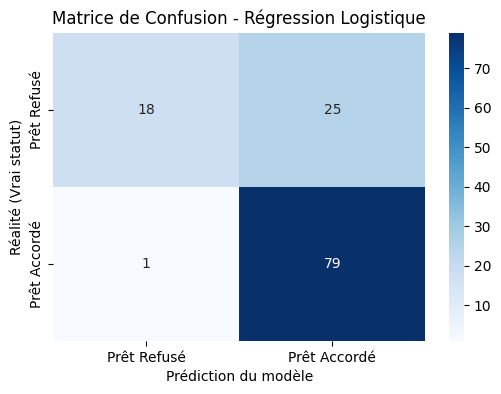

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice entre la réalité (y_test) et les prédictions (y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)

# 2. Affichage graphique
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prêt Refusé', 'Prêt Accordé'], 
            yticklabels=['Prêt Refusé', 'Prêt Accordé'])

plt.xlabel('Prédiction du modèle')
plt.ylabel('Réalité (Vrai statut)')
plt.title('Matrice de Confusion - Régression Logistique')
plt.show()

### 5.1.1 Analyse des résultats de la matrice

Ce tableau nous montre exactement où le modèle a réussi et où il s'est trompé sur les 123 dossiers de test :

*   **79 dossiers (En bas à droite) :** Ce sont les clients qui méritaient le prêt et à qui le modèle a dit "OUI". C'est une grande réussite.
*   **18 dossiers (En haut à gauche) :** Ce sont les clients risqués que le modèle a bien détectés et à qui il a dit "NON". La banque a évité de perdre de l'argent ici.

#### **Les erreurs du modèle :**
1.  **25 erreurs de type "Risque financier" (En haut à droite) :** Le modèle a dit "OUI" à 25 personnes qui étaient pourtant risquées en réalité. C'est le point faible du modèle : il est un peu trop optimiste.
2.  **1 seule erreur de type "Trop sévère" (En bas à gauche) :** Le modèle n'a refusé qu'un seul bon client par erreur. C'est excellent, car la banque ne perd presque aucun client solvable.

### 5.2 Le Score F1 (Équilibre Précision / Rappel)
Le Score F1 est notre note de qualité principale. Il prouve que le modèle est équilibré : il est capable de trouver les bons clients (Rappel) tout en restant assez fiable dans ses réponses (Précision).

In [19]:
from sklearn.metrics import f1_score

score_f1 = f1_score(y_test, y_pred_lr)
print(f"Le Score F1 du modèle est de : {score_f1:.2f}")

Le Score F1 du modèle est de : 0.86


#### 5.2.1 Observation sur le Score F1 : 0.86

Le Score F1 est la note globale de qualité de notre modèle. Avec un résultat de **0.86** (sur un maximum de 1.0), nous pouvons tirer les conclusions suivantes :

1.  **Une grande fiabilité :** Un score de 0.86 est considéré comme très performant. Cela montre que le modèle ne se trompe pas souvent.
2.  **Un bon équilibre :** Ce score prouve que le modèle a trouvé le bon équilibre. Il est capable de valider la grande majorité des bons clients (**Rappel**) tout en restant assez prudent pour ne pas dire "Oui" à n'importe qui (**Précision**).
3.  **Supériorité sur le hasard :** Ce score est bien plus élevé que si l'on décidait au hasard. Il confirme que notre automatisation est prête à être utilisée par la banque.

**En résumé :** Ce score de 0.86 valide techniquement notre solution. Le modèle est robuste et équilibré.

### 5.3 La Courbe ROC
Cette courbe mesure la capacité du modèle à bien séparer les "bons" des "mauvais" dossiers. Plus la courbe monte vers le coin en haut à gauche, plus le modèle est performant. Le score **AUC** (Aire sous la courbe) nous donne une note finale de fiabilité.

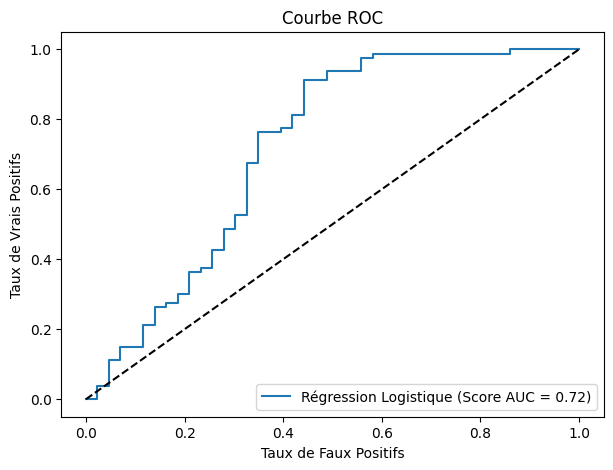

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
# 1. Calcul des probabilités
y_probs = model_lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# 2. Affichage
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Régression Logistique (Score AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Ligne de hasard
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC')
plt.legend()
plt.show()

#### 5.3.1 Observation sur la Courbe ROC (AUC : 0.72)

La courbe ROC est un outil visuel qui nous permet de mesurer la puissance de "discernement" du modèle. 

1.  **Comparaison avec le hasard :** La ligne pointillée noire représente le hasard (un choix fait à pile ou face). On observe que notre courbe bleue est **nettement au-dessus**, ce qui prouve que le modèle a réellement appris à différencier un bon client d'un client risqué.
2.  **Le score AUC (0.72) :** L'aire sous la courbe (AUC) nous donne une note de **0.72 sur 1.0**. 
    *   Un score de 0.50 est mauvais (hasard).
    *   Un score de 1.0 est parfait.
    *   **Notre score de 0.72 est considéré comme "Bon"**. Cela signifie que dans 72 % des cas, le modèle est capable de classer correctement un client solvable au-dessus d'un client non solvable.
3.  **Conclusion :** Ce graphique confirme que la Régression Logistique est un moteur fiable pour l'automatisation des prêts chez Dream Housing Finance. Bien qu'il ne soit pas parfait, il apporte une aide à la décision très solide.

### 5.4 Analyse de l'importance des variables
Ici, nous regardons quels critères ont le plus influencé le modèle pour dire "OUI" ou "NON" au prêt. C'est l'étape la plus importante pour le marketing.

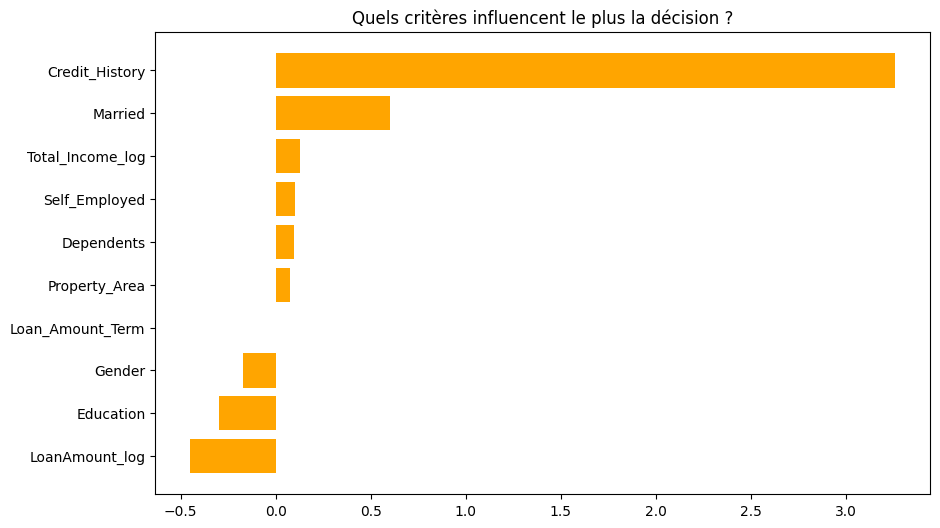

In [22]:
# On regarde les coefficients du modèle
importance = model_lr.coef_[0]
variables = X.columns

# Création d'un petit tableau pour visualiser
df_importance = pd.DataFrame({'Critère': variables, 'Poids': importance})
df_importance = df_importance.sort_values(by='Poids', ascending=True)

# Affichage graphique
plt.figure(figsize=(10,6))
plt.barh(df_importance['Critère'], df_importance['Poids'], color='orange')
plt.title('Quels critères influencent le plus la décision ?')
plt.show()

#### 5.4.1 Analyse de l'importance des critères de décision

Ce graphique nous révèle quels facteurs pèsent le plus dans la décision finale du modèle. Plus la barre est longue, plus le critère est important.

1.  **Le champion incontesté : L'Historique de Crédit (`Credit_History`)**
    C'est, de très loin, le facteur le plus puissant. La barre est la plus longue et se dirige vers la droite. Cela signifie qu'avoir un bon historique de crédit est le meilleur moyen d'obtenir un "OUI" du modèle.

2.  **Les facteurs qui aident (Barres vers la droite) :**
    *   **Le mariage (`Married`) :** Être marié semble favoriser légèrement l'approbation du prêt dans ce jeu de données.
    *   **Le revenu total (`Total_Income_log`) :** Plus le revenu global du foyer est élevé, plus le modèle tend à donner un accord.

3.  **Les facteurs qui freinent (Barres vers la gauche) :**
    *   **Le montant du prêt (`LoanAmount_log`) :** C'est logique : plus la somme demandée est importante, plus le modèle devient prudent et tend à dire "NON".
    *   **L'éducation (`Education`) :** Le modèle prend en compte le niveau d'étude (dans notre encodage, être diplômé aide à obtenir le prêt).

**Conclusion pour la banque :**
Le modèle se comporte de manière très rationnelle et "bancaire". Il donne la priorité absolue au passé financier (crédit) et à la solidité du dossier (revenus vs montant demandé). Les critères personnels comme le genre (`Gender`) ont un impact beaucoup plus faible, ce qui garantit une certaine équité dans le traitement des dossiers.

# VI - Déploiement et Recommandations (Deployment)

Cette phase finale consiste à transformer nos résultats en une solution concrète pour Dream Housing Finance.

### 6.1 Rapport de synthèse et Profils types
Notre analyse a permis de valider un modèle de **Régression Logistique** avec une précision de **79 %** et un score F1 de **0.86**. 

#### **Le profil type du client éligible :**
Grâce à nos analyses, nous pouvons définir le client "idéal" pour un accord de prêt immédiat :
*   **Critère n°1 :** Possède un historique de crédit positif (sans incident de paiement).
*   **Zone :** Réside de préférence en zone **Semi-urbaine** (segment affichant le meilleur taux de succès).
*   **Situation :** Est marié et dispose d'un revenu de foyer (Total Income) solide.
*   **Équilibre :** Demande un montant de prêt raisonnable par rapport à ses revenus.

**Note éthique :** Le modèle n'accorde pas d'importance significative au genre, garantissant un traitement équitable des demandes.

### 6.2 Prototype d'application (Simulateur)
Pour cette partie, nous allons créer une fonction Python simple qui simule le comportement d'une application. Un agent de crédit pourrait utiliser ce code pour tester un nouveau dossier.

In [24]:
import numpy as np
import pandas as pd

# --- LE CODE DU SIMULATEUR ---
def simulateur_decision(historique_credit, revenu_total, montant_pret, zone_geo, marie):
    # 1. Calcul du revenu total et transformation log
    log_revenu = np.log(revenu_total)
    log_pret = np.log(montant_pret)
    
    # 2. Création du tableau de données pour le modèle
    # On respecte l'ordre exact des colonnes que le modèle a appris
    client_test = pd.DataFrame({
        'Gender': [1], 
        'Married': [marie], 
        'Dependents': [0], 
        'Education': [0], 
        'Self_Employed': [0], 
        'Loan_Amount_Term': [360], 
        'Credit_History': [historique_credit], 
        'Property_Area': [zone_geo],
        'Total_Income_log': [log_revenu], 
        'LoanAmount_log': [log_pret]
    })
    
    # 3. Prédiction (Utilise le modèle que nous avons entraîné en partie IV)
    decision = model_lr.predict(client_test)[0]
    probabilite = model_lr.predict_proba(client_test)[0][1]
    
    # 4. AFFICHAGE DES RÉSULTATS (C'est cette partie qui écrit à l'écran)
    print("\n" + "="*40)
    print("      DREAM HOUSING FINANCE - IA")
    print("="*40)
    if decision == 1:
        print(f"✅ RÉSULTAT : PRÊT ACCORDÉ")
        print(f"👉 Confiance du modèle : {probabilite*100:.2f}%")
    else:
        print(f"❌ RÉSULTAT : PRÊT REFUSÉ")
        print(f"👉 Risque estimé : {(1-probabilite)*100:.2f}%")
    print("="*40 + "\n")

# --- L'APPEL DE LA FONCTION (C'est cette ligne qui déclenche l'affichage) ---
# Ici on teste un client avec : Crédit OK (1.0), 6000$ de revenu, 150$ de prêt, Zone Semi-Urbaine (1), Marié (1)
simulateur_decision(1.0, 6000, 150, 1, 1)



      DREAM HOUSING FINANCE - IA
✅ RÉSULTAT : PRÊT ACCORDÉ
👉 Confiance du modèle : 81.52%



### 6.3 Suivi et Maintenance
Le marché immobilier et la situation économique évoluent. Pour que cet outil reste performant, nous recommandons :

1.  **Réévaluation semestrielle :** Ré-entraîner le modèle tous les 6 mois avec les nouvelles données de prêts accordés et les éventuels défauts de paiement constatés.
2.  **Surveillance des "Faux Positifs" :** Suivre de près les 25 % d'erreurs identifiées dans la matrice de confusion pour affiner les critères de rejet.
3.  **Extension des données :** Intégrer de nouvelles variables si possible, comme le taux d'endettement actuel du client ou son épargne, pour améliorer le score AUC de 0.72 à 0.85.


In [ ]:
import joblib
# On enregistre le modèle sur notre ordinateur
joblib.dump(model_lr, 'mon_modele_pret.pkl')
print("✅ Modèle sauvegardé sous le nom 'mon_modele_pret.pkl'")

✅ Modèle sauvegardé sous le nom 'mon_modele_pret.pkl'
